# SVM: pilot model
Space oddity - David Bowie

“Predict whether a given EEG window belongs to the preictal state or the non-preictal state, using engineered features derived from that window, in an intrapatient temporally ordered setting.”

## 1. Input:
Table with A. features, B. label and C. Metadata. 

**A. Feature columns:** 
These go into the model. Training. These enter into the SVM

**B. Label column:**
This is the target only.

**C. Metadata column:**
These are used for tracking, splitting, and interpretation, but not for training.

In [1]:
# Importing the df from pickle
import pandas as pd
from pathlib import Path

BASE_DIR = Path("/home/tperezsanchez/FoundationModel_EEG_Dissertation/EEG_data_vis/results/")
OUTPUT_DIR = BASE_DIR / "intermediate_results"

df_path = OUTPUT_DIR / "df_final.pkl"

df_final = pd.read_pickle(df_path)

df_final.head()
#print(df_final.shape)

,file_name,window_id,start_sample_x,end_sample_x,fs_x,mean_EEG_SQ_D-SQ_C,std_EEG_SQ_D-SQ_C,var_EEG_SQ_D-SQ_C,rms_EEG_SQ_D-SQ_C,ptp_EEG_SQ_D-SQ_C,...,gamma_power_EEG_SQ_P-SQ_C,peak_frequency_EEG_SQ_P-SQ_C,start_sample_y,end_sample_y,fs_y,n_channels,seizure_onsets,window_start_time,window_end_time,preictal
0,XB47Y_35_preproc_full.npz,0,0,2070,207.031055,0.146486,1.847046,3.411580,1.852846,21.921715,...,0.576220,0.500075,0,2070,207.031055,2,[],2019-10-29 09:31:04.000000,2019-10-29 09:31:13.998500,0
1,XB47Y_35_preproc_full.npz,1,2070,4140,207.031055,0.028678,1.038813,1.079133,1.039209,6.887297,...,0.411484,0.500075,2070,4140,207.031055,2,[],2019-10-29 09:31:13.998500,2019-10-29 09:31:23.997000,0
2,XB47Y_35_preproc_full.npz,2,4140,6210,207.031055,-0.025461,1.736126,3.014132,1.736312,15.536640,...,0.452839,0.500075,4140,6210,207.031055,2,[],2019-10-29 09:31:23.997000,2019-10-29 09:31:33.995500,0
3,XB47Y_35_preproc_full.npz,3,6210,8280,207.031055,-0.023023,1.346264,1.812426,1.346460,11.984170,...,1.454117,0.500075,6210,8280,207.031055,2,[],2019-10-29 09:31:33.995500,2019-10-29 09:31:43.994000,0
4,XB47Y_35_preproc_full.npz,4,8280,10350,207.031055,0.010164,2.057101,4.231666,2.057127,16.416668,...,3.882542,0.500075,8280,10350,207.031055,2,[],2019-10-29 09:31:43.994000,2019-10-29 09:31:53.992500,0


## 2. Sort dataframe by time:

Why this matters:
If the rows are shuffled or mixed across recordings, a temporal split becomes meaningless.
**Take into consideration:**

- Gaps in recording
- Imbalance between preictal and non-preictal

Training, Validation and Test should have the same proportion in the **spliting**
80%, 10%, 10% (?) ask Richard and Dom. 



In [2]:
df = df_final.copy()
df["window_start_time"] = pd.to_datetime(df["window_start_time"])
df = df.sort_values("window_start_time").reset_index(drop=True)

In [3]:
print(df["window_start_time"].head())
print(df["window_start_time"].tail())
# it checks with mapping, as it is the last day of recording (2019-12-13)

0   2019-10-29 09:31:04.000000
1   2019-10-29 09:31:13.998500
2   2019-10-29 09:31:23.997000
3   2019-10-29 09:31:33.995500
4   2019-10-29 09:31:43.994000
Name: window_start_time, dtype: datetime64[ns]
291108   2019-12-13 10:50:17.996999999
291109   2019-12-13 10:50:27.995499999
291110   2019-12-13 11:13:30.000000000
291111   2019-12-13 11:13:39.998499999
291112   2019-12-13 11:13:49.996999999
Name: window_start_time, dtype: datetime64[ns]


## 3. initial data quality checks
Check:

- missing values
- infinite values
- duplicated rows
- constant or near-constant features
- extreme outliers
- severe feature correlation

Purpose:

- avoid technical instability
- avoid nonsense inputs going into the scaler and SVM
- understand whether some features are redundant

At pilot stage, there is not need aggressive feature selection yet. But it should at least remove:

- broken columns
- constant columns
 -obviously invalid columns

In [4]:
import numpy as np
import pandas as pd
df = df_final.copy()

print("==== BASIC INFO ====")
print(df.shape)
print(df.dtypes.value_counts())

# -------------------------
# 1. Missing values
# -------------------------
print("\n==== MISSING VALUES ====")
missing = df.isna().sum()
print(missing[missing > 0])

# -------------------------
# 2. Infinite values
# -------------------------
print("\n==== INFINITE VALUES ====")
numeric_df = df.select_dtypes(include=[np.number])
inf_counts = np.isinf(numeric_df).sum()
print(inf_counts[inf_counts > 0])

# -------------------------
# 3. Duplicated rows
# -------------------------
print("\n==== DUPLICATED ROWS ====")
dup_cols = ["file_name", "window_id", "window_start_time", "window_end_time"]

n_dup = df.duplicated(subset=dup_cols).sum()
print(f"Duplicated windows based on key identifiers: {n_dup}")

# -------------------------
# 4. Constant / near-constant features
# -------------------------
print("\n==== CONSTANT / LOW VARIANCE FEATURES ====")

# constant
constant_cols = [col for col in numeric_df.columns if numeric_df[col].nunique() <= 1]
print(f"Constant features: {constant_cols}")

# near-constant (low std)
low_var_cols = numeric_df.std()[numeric_df.std() < 1e-6].index.tolist()
print(f"Near-constant features: {low_var_cols}")

# -------------------------
# 5. Extreme outliers (IQR method)
# -------------------------
print("\n==== OUTLIERS (IQR METHOD) ====")

outlier_summary = {}

for col in numeric_df.columns:
    q1 = numeric_df[col].quantile(0.25)
    q3 = numeric_df[col].quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 3 * iqr
    upper = q3 + 3 * iqr
    
    n_outliers = ((numeric_df[col] < lower) | (numeric_df[col] > upper)).sum()
    
    if n_outliers > 0:
        outlier_summary[col] = n_outliers

print("Columns with outliers:", outlier_summary)

# -------------------------
# 6. Feature correlation
# -------------------------
print("\n==== HIGH CORRELATION FEATURES ====")

corr_matrix = numeric_df.corr().abs()

# upper triangle
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [(col, idx) for col in upper.columns for idx in upper.index if upper.loc[idx, col] > 0.95]

print(f"Highly correlated pairs (>0.95): {high_corr[:10]}")  # show first 10
print(f"Total pairs: {len(high_corr)}")

==== BASIC INFO ====
(291113, 41)
float64           16
float32           14
int64              7
object             2
datetime64[ns]     2
Name: count, dtype: int64

==== MISSING VALUES ====
skew_EEG_SQ_D-SQ_C        117
kurtosis_EEG_SQ_D-SQ_C    133
skew_EEG_SQ_P-SQ_C        119
kurtosis_EEG_SQ_P-SQ_C    129
dtype: int64

==== INFINITE VALUES ====
kurtosis_EEG_SQ_D-SQ_C    2
kurtosis_EEG_SQ_P-SQ_C    3
dtype: int64

==== DUPLICATED ROWS ====
Duplicated windows based on key identifiers: 0

==== CONSTANT / LOW VARIANCE FEATURES ====
Constant features: ['n_channels']


/home/tperezsanchez/micromamba/envs/domain_expansion/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


Near-constant features: ['fs_x', 'fs_y', 'n_channels']

==== OUTLIERS (IQR METHOD) ====
Columns with outliers: {'fs_x': np.int64(5020), 'mean_EEG_SQ_D-SQ_C': np.int64(19428), 'std_EEG_SQ_D-SQ_C': np.int64(4399), 'var_EEG_SQ_D-SQ_C': np.int64(18942), 'rms_EEG_SQ_D-SQ_C': np.int64(4399), 'line_length_EEG_SQ_D-SQ_C': np.int64(3583), 'skew_EEG_SQ_D-SQ_C': np.int64(1352), 'kurtosis_EEG_SQ_D-SQ_C': np.int64(9046), 'mean_EEG_SQ_P-SQ_C': np.int64(5954), 'std_EEG_SQ_P-SQ_C': np.int64(3660), 'var_EEG_SQ_P-SQ_C': np.int64(15527), 'rms_EEG_SQ_P-SQ_C': np.int64(3662), 'line_length_EEG_SQ_P-SQ_C': np.int64(3109), 'skew_EEG_SQ_P-SQ_C': np.int64(12193), 'kurtosis_EEG_SQ_P-SQ_C': np.int64(23335), 'delta_power_EEG_SQ_D-SQ_C': np.int64(24058), 'theta_power_EEG_SQ_D-SQ_C': np.int64(24026), 'alpha_power_EEG_SQ_D-SQ_C': np.int64(26301), 'beta_power_EEG_SQ_D-SQ_C': np.int64(14038), 'gamma_power_EEG_SQ_D-SQ_C': np.int64(17452), 'peak_frequency_EEG_SQ_D-SQ_C': np.int64(88643), 'delta_power_EEG_SQ_P-SQ_C': np.i

In [7]:
# 1. fix inf
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. drop missing
df.dropna(inplace=True)

# 3. drop useless columns
#df = df.drop(columns=["n_channels", "fs_x", "fs_y"])

In [8]:
df_SVM = df
# I want to work with df_SVM instead of df 

## 4. Splitting: 
Because this is intrapatient and temporal, the split should be:

earlier data = training
later data = testing
**spliting**
80%, 10%, 10% (?) ask Richard and Dom. 

### 4.1 Exclude useless columns for SVM training

In [9]:
# target
y = df_SVM["preictal"].astype(int)

# ---- feature columns ----
exclude_cols = [
    "preictal",
    "file_name",
    "window_id",
    "start_sample_x", "end_sample_x",
    "start_sample_y", "end_sample_y",
    "window_start_time", "window_end_time",
    "fs_x", "fs_y",
    "n_channels",
    "seizure_onsets"
]

feature_cols = [c for c in df_SVM.columns if c not in exclude_cols]
X = df_SVM[feature_cols]

# It is necessary to calculate this ratio to evalute if it is possible to have the same proportion of pre-ictal windows in all the splitting Sets.
# probably not, but still try no to make it to imbalance
global_ratio = y.mean()
print("Global preictal ratio:", global_ratio)
# aprox: Global preictal ratio: 0.0033885723319288744

Global preictal ratio: 0.0033885723319288744


### 4.2 Search for best candidates for splitting

In [10]:
# set ideal train, val and test splitting sizes
n = len(df)

ideal_train = 0.80
ideal_val = 0.10
ideal_test = 0.10

In [11]:
# generate candidates for the splitting

# possible positions where training ends
train_candidates = range(int(0.70 * n), int(0.90 * n), max(1, n // 1000))
# possible positions where validation ends 
val_candidates = range(int(0.05 * n), int(0.20 * n), max(1, n // 1000))

# search for the best temporal split
best = None
best_score = np.inf



In [12]:
for train_end in train_candidates:
    for val_size in val_candidates:
        val_end = train_end + val_size

        if val_end >= n:
            continue

        # temporal subsets because df is already sorted by window_start_time
        # SPLIT STARTS HERE
        y_train = y.iloc[:train_end]
        y_val = y.iloc[train_end:val_end]
        y_test = y.iloc[val_end:]

        # require both classes in every split
        # MAKE SURE OF THE PRESENCE OF EACH CLASS IN EVERY SET
        if y_train.nunique() < 2 or y_val.nunique() < 2 or y_test.nunique() < 2:
            continue

        # size closeness to 80/10/10
        # measure how close is to the ideal proportion
        train_frac = len(y_train) / n
        val_frac = len(y_val) / n
        test_frac = len(y_test) / n

        size_score = (
            abs(train_frac - 0.80) +
            abs(val_frac - 0.10) +
            abs(test_frac - 0.10)
        )

        # class ratio closeness to global ratio
        # measure how close is the preictal proportions 
        ratio_score = (
            abs(y_train.mean() - global_ratio) +
            abs(y_val.mean() - global_ratio) +
            abs(y_test.mean() - global_ratio)
        )

        # combined score for choosing the best score
        score = size_score + ratio_score * 3

        if score < best_score:
            best_score = score
            best = (train_end, val_end)


### 4.3 Save final split

In [13]:
train_end, val_end = best

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

### 4.4 Check results


In [14]:
print("\nSet sizes:")
print(f"Train: {len(X_train)} ({len(X_train)/n:.3%})")
print(f"Val:   {len(X_val)} ({len(X_val)/n:.3%})")
print(f"Test:  {len(X_test)} ({len(X_test)/n:.3%})")

print("\nPreictal ratios:")
print(f"Global: {y.mean():.5f}")
print(f"Train:  {y_train.mean():.5f}")
print(f"Val:    {y_val.mean():.5f}")
print(f"Test:   {y_test.mean():.5f}")

print("\nTime ranges:")
print("Train:", df.loc[0, "window_start_time"], "->", df.loc[train_end - 1, "window_start_time"])
print("Val:  ", df.loc[train_end, "window_start_time"], "->", df.loc[val_end - 1, "window_start_time"])
print("Test: ", df.loc[val_end, "window_start_time"], "->", df.loc[n - 1, "window_start_time"])


Set sizes:
Train: 232684 (79.966%)
Val:   29048 (9.983%)
Test:  29246 (10.051%)

Preictal ratios:
Global: 0.00339
Train:  0.00337
Val:    0.00100
Test:   0.00595

Time ranges:
Train: 2019-10-29 09:31:04 -> 2019-12-02 20:57:05.854499316
Val:   2019-12-02 20:57:15.852999316 -> 2019-12-06 21:40:58.993999346
Test:  2019-12-06 21:41:08.992499346 -> 2019-12-11 19:43:56.992999563


## 5. Scaling features

SVM is very sensitive to feature scale.

If one feature has values around 1000 and another around 0.01, the large-scale feature will dominate the geometry.

Use standardization:

subtract mean
divide by standard deviation

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


## 6. Linear SVC
SVM + class_weight='balanced'

The set has a big difference between preictal and non-preictal

### 6.1 Training


The parameter C in a Support Vector Machine (SVM) is the regularization parameter. TRADEOFF. 

It controls the trade-off between:

Maximizing the margin (simpler, more generalizable model)
Minimizing classification errors on the training data

-  Large C (e.g., 10, 100)
Strong penalty for misclassification
The model tries to classify all training points correctly
Leads to:
More complex decision boundary
Higher risk of overfitting

idea behind: “Avoid errors at all costs”

- Small C (e.g., 0.01, 0.1)
Allows some misclassifications
Prioritizes a wider margin
Leads to:
Simpler model
Better generalization

Idea behind: “Accept some errors to stay robust”
    

In [ ]:
# try with many C values and check the best ones
# manual hyperparameter search.

In [65]:
best_c = None
best_val_score = 0
c_values = [0.01, 0.1, 1, 10, 100,1000,10000,1000000]

for c in c_values:
    model = LinearSVC(C=c, class_weight='balanced', max_iter=10000)
    model.fit(X_train_scaled, y_train)
    
    score = model.score(X_val_scaled, y_val) 
    print(score)
    if score > best_val_score:
        best_val_score = score
        best_c = c

print(f"Best C: {best_c}")
# train model using the Best C, among the ones that I tried 

0.566510603139631
0.5668892866978794
0.5666827320297438
0.5720187276232442
0.5775957036629028
0.5791792894519416
0.5794891214541449
0.5795235472321675
Best C: 1000000


### 6.1.1 Linear with C=1

In [42]:
import time
from sklearn.svm import LinearSVC

model = LinearSVC(C=1.0, class_weight='balanced')
start = time.time()

model.fit(X_train_scaled, y_train)

end = time.time()

print(f"Training time: {end - start:.2f} seconds")
# expected : Training time: 3.37 secondsfrom sklearn.metrics import classification_report
y_val_pred = model.predict(X_val_scaled)

print(f"\nC = {model.C}")
print(classification_report(y_val, y_val_pred))

Training time: 3.45 seconds

C = 1.0
              precision    recall  f1-score   support

           0       1.00      0.57      0.72     29019
           1       0.00      0.79      0.00        29

    accuracy                           0.57     29048
   macro avg       0.50      0.68      0.36     29048
weighted avg       1.00      0.57      0.72     29048



#### 6.1.2.1 Evaluation of training

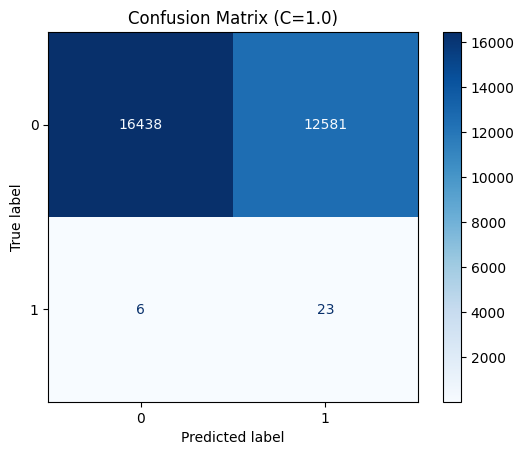

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title(f"Confusion Matrix (C={model.C})")
plt.show()

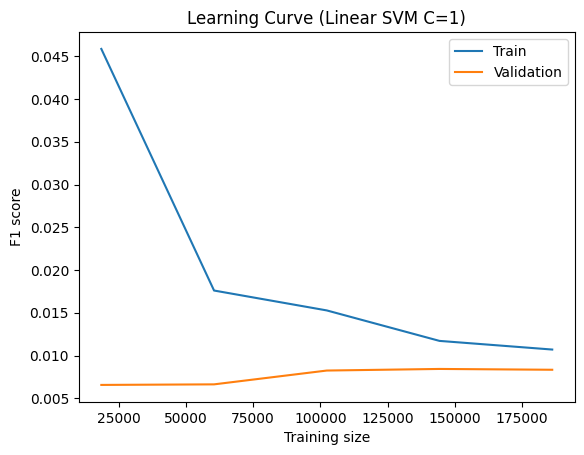

In [44]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1',   # importante en tu caso
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Train")
plt.plot(train_sizes, val_mean, label="Validation")
plt.xlabel("Training size")
plt.ylabel("F1 score")
plt.title("Learning Curve (Linear SVM C=1)")
plt.legend()
plt.show()

### 6.1.2 Linear with C=10

In [29]:
model = LinearSVC(C=10.0, class_weight='balanced')
import time

start = time.time()

model.fit(X_train_scaled, y_train)

end = time.time()

print(f"Training time: {end - start:.2f} seconds")
y_val_pred = model.predict(X_val_scaled)

print(f"\nC = {model.C}")
print(classification_report(y_val, y_val_pred))

Training time: 5.09 seconds

C = 10.0
              precision    recall  f1-score   support

           0       1.00      0.57      0.73     29019
           1       0.00      0.83      0.00        29

    accuracy                           0.57     29048
   macro avg       0.50      0.70      0.37     29048
weighted avg       1.00      0.57      0.73     29048



#### 6.1.2.1 Evaluation of training

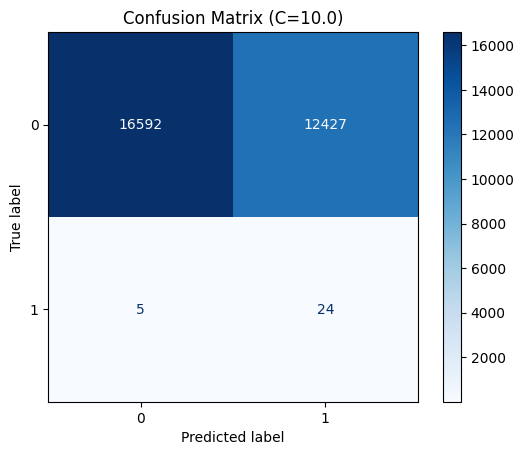

In [30]:
# confussion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title(f"Confusion Matrix (C={model.C})")
plt.show()

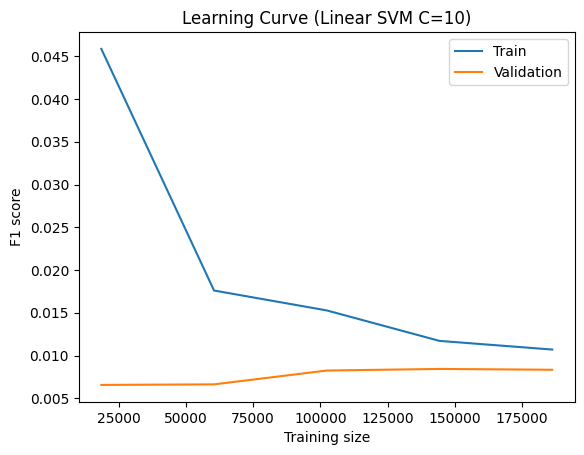

In [34]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1',   # importante en tu caso
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Train")
plt.plot(train_sizes, val_mean, label="Validation")
plt.xlabel("Training size")
plt.ylabel("F1 score")
plt.title("Learning Curve (Linear SVM C=10)")
plt.legend()
plt.show()

### 6.1.3 Linear with C=100

In [46]:
model = LinearSVC(C=100.0, class_weight='balanced')
import time

start = time.time()

model.fit(X_train_scaled, y_train)

end = time.time()

print(f"Training time: {end - start:.2f} seconds")
y_val_pred = model.predict(X_val_scaled)

print(f"\nC = {model.C}")
print(classification_report(y_val, y_val_pred))

Training time: 7.77 seconds

C = 100.0
              precision    recall  f1-score   support

           0       1.00      0.58      0.73     29019
           1       0.00      0.79      0.00        29

    accuracy                           0.58     29048
   macro avg       0.50      0.69      0.37     29048
weighted avg       1.00      0.58      0.73     29048



#### 6.1.3.1 Model evaluation
**Classification table:**
- precision
- recall (sensitivity) for the preictal class
- F1-score for the preictal class
- balanced accuracy
- preferably also PR-AUC if available

**Confusion matrix**

**Learning Curves**

**ROC-AUC curves**


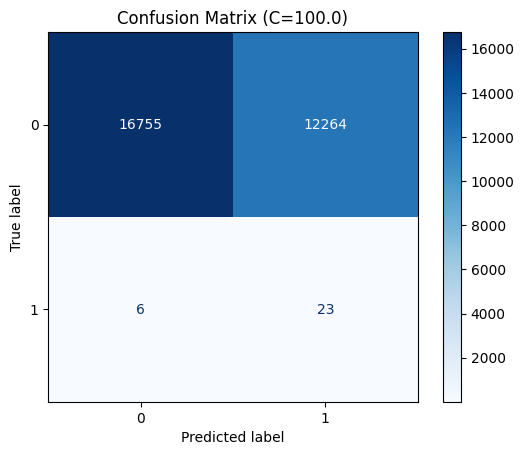

In [47]:
# confussion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title(f"Confusion Matrix (C={model.C})")
plt.show()

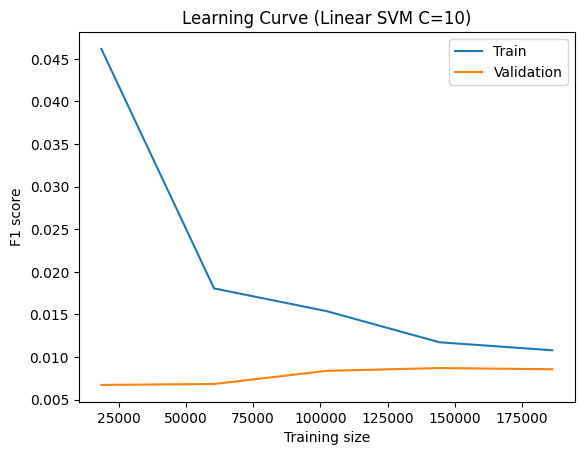

In [48]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1',   # importante en tu caso
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Train")
plt.plot(train_sizes, val_mean, label="Validation")
plt.xlabel("Training size")
plt.ylabel("F1 score")
plt.title("Learning Curve (Linear SVM C=10)")
plt.legend()
plt.show()

In [49]:
from sklearn.metrics import roc_auc_score, average_precision_score

# decision function from SVM
y_val_scores = model.decision_function(X_val_scaled)

auc_roc = roc_auc_score(y_val, y_val_scores)
auc_pr = average_precision_score(y_val, y_val_scores)

print(f"ROC AUC: {auc_roc:.3f}")
print(f"PR AUC (Average Precision): {auc_pr:.3f}")

ROC AUC: 0.726
PR AUC (Average Precision): 0.002


## 7 RBF(Radial Basis Function) SVC

In [17]:
from sklearn.utils import resample
from sklearn.svm import SVC

# 1. Try more conservative parameters
model = SVC(
    kernel='rbf',
    C=1000.0,           
    gamma='scale',   
    class_weight='balanced'
)

# 2. Instead of the first 50k, use stratified sampling
# This ensures the 50k samples represent the whole training period
X_shuffled, y_shuffled = resample(
    X_train_scaled, 
    y_train, 
    n_samples=50000, 
    replace=False, 
    stratify=y_train, 
    random_state=42
)

model.fit(X_shuffled, y_shuffled)

,C,1000.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [71]:
y_val_pred = model.predict(X_val_scaled)
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96     29019
           1       0.00      0.03      0.00        29

    accuracy                           0.92     29048
   macro avg       0.50      0.48      0.48     29048
weighted avg       1.00      0.92      0.96     29048



### 7.1 manual hyperparameter search.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import f1_score

best_score = 0
best_params = None

C_values = [0.1, 1, 10]
gamma_values = [0.1, 0.01, 0.001]

for C in C_values:
    for gamma in gamma_values:
        
        model = SVC(
            kernel='rbf',
            C=C,
            gamma=gamma,
            class_weight='balanced'
        )
        
        model.fit(X_train_scaled, y_train)
        y_val_pred = model.predict(X_val_scaled)
        
        score = f1_score(y_val, y_val_pred)
        
        print(f"C={C}, gamma={gamma}, F1={score:.4f}")
        
        if score > best_score:
            best_score = score
            best_params = (C, gamma)

print(f"\nBest params: C={best_params[0]}, gamma={best_params[1]}")

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.1, 0.01, 0.001]
}

grid = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced'),
    param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Best params: {'C': 1, 'gamma': 0.01}
Best score: 0.009165755347905001


## 8. Tune hyperparameters

**For linear SVM**

Main parameter:

- C

**For RBF SVM**

Main parameters:

- C
- gamma

## 9. Evaluation

**Classification table:**
- precision
- recall (sensitivity) for the preictal class
- F1-score for the preictal class
- balanced accuracy
- preferably also PR-AUC if available

**Confusion matrix**

**Learning Curves**

**ROC-AUC curves**


# Pilot 2: using RBF and a different split logic:
A common approach in this setting is to use a forward chaining (expanding window) strategy.

The first 80% of the data is divided into equal blocks.
For example, if it is split into four blocks of 20% each:

B1 = 0–20
B2 = 20–40
B3 = 40–60
B4 = 60–80
Test = 80–100

The valid folds, while preserving temporal order, are defined as follows:

Fold 1: train = B1, validation = B2
Fold 2: train = B1 + B2, validation = B3
Fold 3: train = B1 + B2 + B3, validation = B4

Result: 3 folds

In this setup, validation progresses sequentially from one block to the next, and there is no overlap between validation sets.